In [25]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal

In [26]:
class QuadState(TypedDict):
    a : int
    b : int
    c : int 
    
    equation : str
    discriment : float
    result : str

In [37]:
def show_equation(state: QuadState):

    equation = f'{state["a"]}x2+{state["b"]}x+{state["c"]}'
    return {'equation':equation}

def calculate_discriment(state: QuadState):

    discriment = state["b"]**2 - (4*state["a"]*state["c"])
    return {'discriment': discriment}

def real_roots(state : QuadState):
    
    root1 = (-state['b'] + state["discriment"]**0.5)/(2*state["a"])
    root2 = (-state['b'] - state["discriment"]**0.5)/(2*state["a"])
    
    result = f'the roots are {root1} and {root2}'
    return {'result': result}

def repeated_roots(state : QuadState):
    
    root = (-state["b"])/(2*state["a"])
    result = f'onlu reapeating root is {root}'
    return {'result' : result}

def no_real_roots(state : QuadState):
    
    result = f'no real roots'
    return {'result': result}

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['discriment'] > 0:
        return "real_roots"
    elif state['discriment'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"



In [38]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriment', calculate_discriment)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriment')

graph.add_conditional_edges('calculate_discriment', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

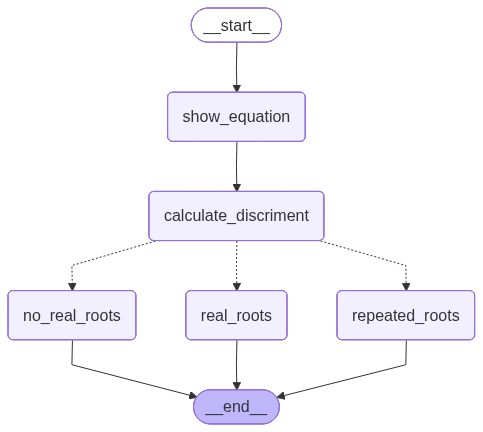

In [39]:
workflow

In [40]:
initial_state = {
    'a': 2, 
    'b': 4,
    'c': 2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x2+4x+2',
 'discriment': 0,
 'result': 'onlu reapeating root is -1.0'}